# Milk Production Time-Series Forecasting

This notebook compares ARIMA-style forecasting models on monthly milk production data and evaluates model stability.



# Dataset: https://raw.githubusercontent.com/plotly/datasets/master/monthly-milk-production-pounds.csv
# =============================================================================


# =============================================================================
# Step 0: Import libraries
# =============================================================================


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


# =============================================================================
# Step 1: Load the dataset
# =============================================================================


In [ ]:
url = 'https://raw.githubusercontent.com/plotly/datasets/master/monthly-milk-production-pounds.csv'
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
df = df.asfreq('MS').ffill()

print(df.head())


            Monthly milk production (pounds per cow)
Month                                               
1962-01-01                                       589
1962-02-01                                       561
1962-03-01                                       640
1962-04-01                                       656
1962-05-01                                       727


# =============================================================================
# Step 2: Visualize the time series
# =============================================================================


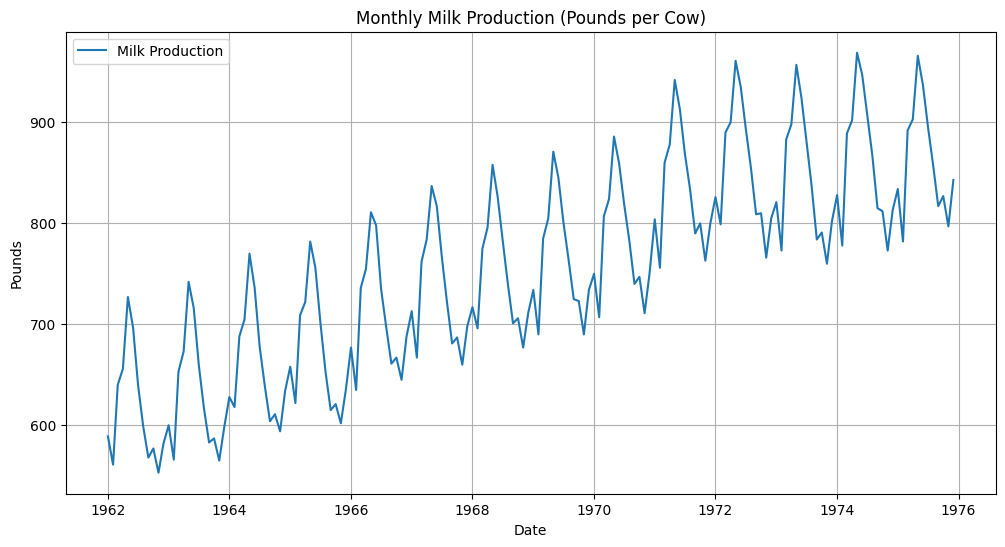

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df, label='Milk Production')
plt.title('Monthly Milk Production (Pounds per Cow)')
plt.xlabel('Date')
plt.ylabel('Pounds')
plt.legend()
plt.grid(True)
plt.show()


# =============================================================================
# Step 3: Train-test split
# =============================================================================


In [ ]:
train = df.iloc[:-12]
test = df.iloc[-12:]

print(f"Training size: {len(train)}")
print(f"Test size: {len(test)}")


Training size: 156
Test size: 12


# =============================================================================
# Step 4: Plot ACF and PACF to Select Parameters
# =============================================================================


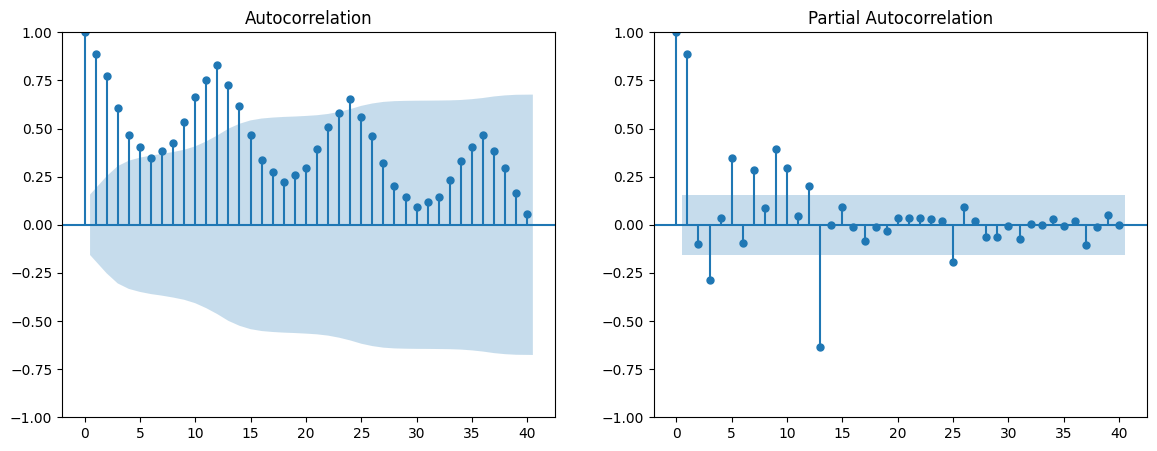

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(train, lags=40, ax=axes[0])
plot_pacf(train, lags=40, ax=axes[1])
plt.show()


# =============================================================================
# Step 5: Build ARIMA Model
# =============================================================================



ARIMA Model Performance:
MAE:  58.91
RMSE: 74.86
MAPE: 6.54%


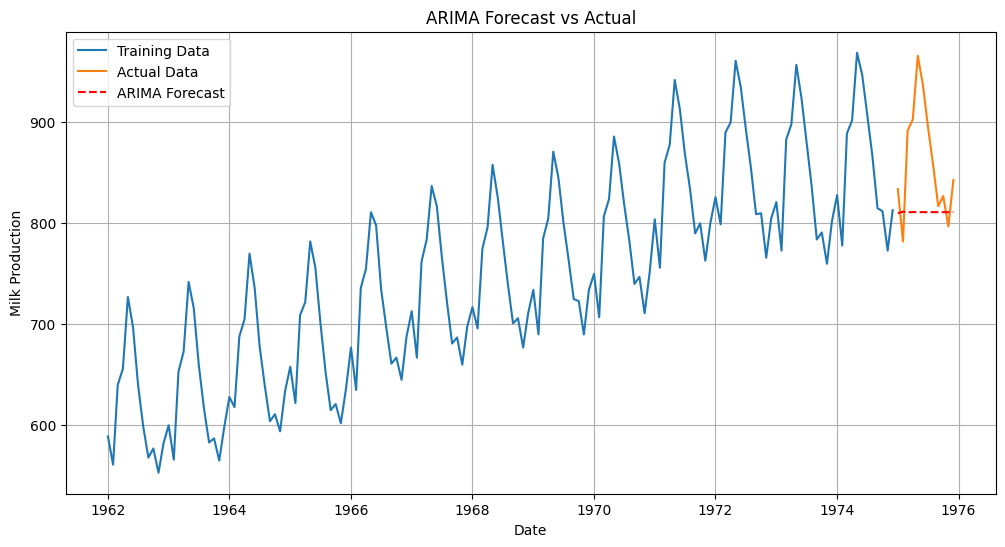

In [ ]:
order = (1, 1, 1)

arima_model = ARIMA(train, order=order)
arima_results = arima_model.fit()

# Forecast
forecast_steps = len(test)
arima_forecast = arima_results.forecast(steps=forecast_steps)

# Evaluation
mae_arima = mean_absolute_error(test, arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(test, arima_forecast))
mape_arima = mean_absolute_percentage_error(test, arima_forecast)

print("\nARIMA Model Performance:")
print(f"MAE:  {mae_arima:.2f}")
print(f"RMSE: {rmse_arima:.2f}")
print(f"MAPE: {mape_arima:.2%}")

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(train, label='Training Data')
plt.plot(test, label='Actual Data')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast', linestyle='--', color='red')
plt.title('ARIMA Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Milk Production')
plt.legend()
plt.grid(True)
plt.show()

# =============================================================================
# Step 6: Residual analysis
# =============================================================================


<Figure size 1200x500 with 0 Axes>

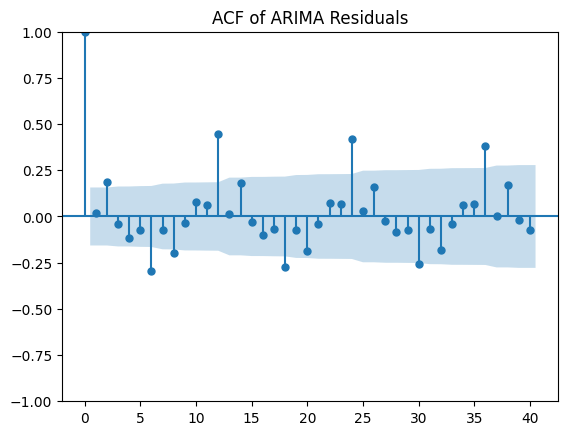

In [ ]:
residuals = arima_results.resid

plt.figure(figsize=(12, 5))
plot_acf(residuals, lags=40)
plt.title('ACF of ARIMA Residuals')
plt.show()

# =============================================================================
# Step 7: Build SARIMA Model (Write by Yourself)
# =============================================================================

# Please build a SARIMA model based on the ARIMA example above.
# - Use the SARIMAX function.
# - Select the order (p, d, q) and seasonal_order (P, D, Q, s) by yourself.
# - Follow the same forecasting and evaluation steps as in the ARIMA example.

# Write your SARIMA model code below:

# =============================================================================



SARIMA Model Performance:
MAE:  9.54
RMSE: 10.65
MAPE: 1.11%


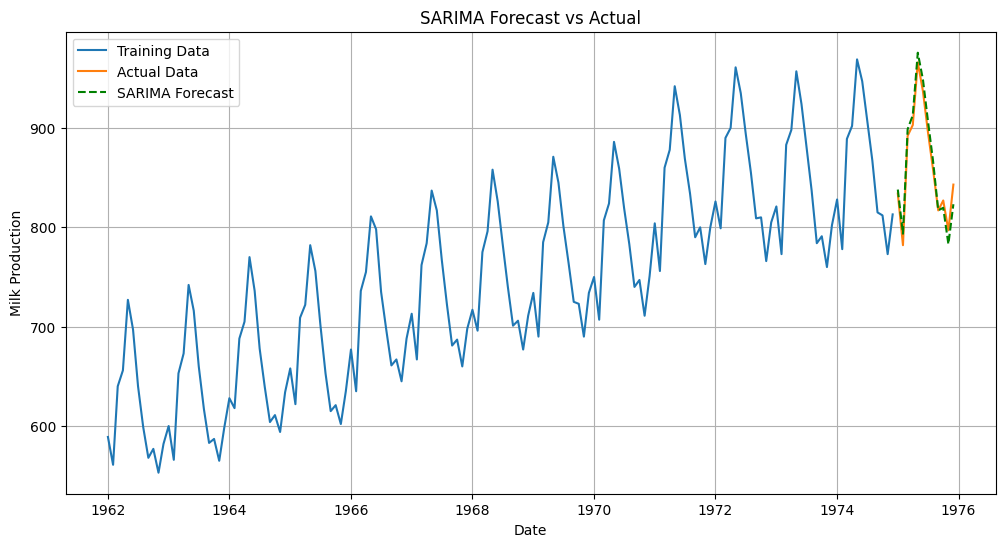

<Figure size 1200x500 with 0 Axes>

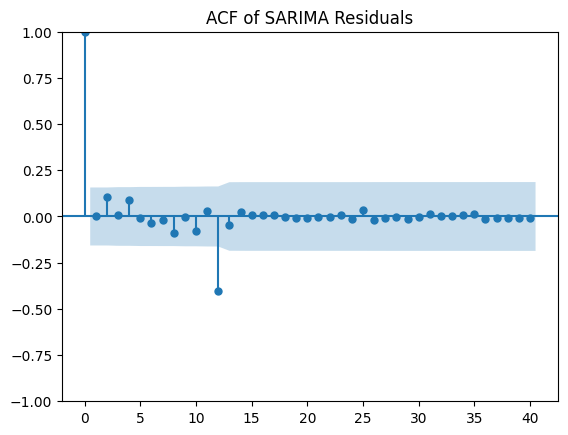

In [ ]:
seasonal_order = (1, 1, 1, 12)
order = (1, 1, 1)

sarima_model = SARIMAX(train, order=order, seasonal_order=seasonal_order,enforce_stationarity=False,enforce_invertibility=False)
sarima_results = sarima_model.fit(disp=False)

# Forecast
sarima_forecast = sarima_results.forecast(steps=len(test))

mae_sarima= mean_absolute_error(test, sarima_forecast)
rmse_sarima = np.sqrt(mean_squared_error(test, sarima_forecast))
mape_sarima = mean_absolute_percentage_error(test, sarima_forecast)

print("\nSARIMA Model Performance:")
print(f"MAE:  {mae_sarima:.2f}")
print(f"RMSE: {rmse_sarima:.2f}")
print(f"MAPE: {mape_sarima:.2%}")

plt.figure(figsize=(12, 6))
plt.plot(train, label='Training Data')
plt.plot(test, label='Actual Data')
plt.plot(test.index, sarima_forecast, label='SARIMA Forecast', linestyle='--', color='green')
plt.title('SARIMA Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Milk Production')
plt.legend()
plt.grid(True)
plt.show()

sarima_residuals = sarima_results.resid
plt.figure(figsize=(12, 5))
plot_acf(sarima_residuals, lags=40)
plt.title('ACF of SARIMA Residuals')
plt.show()



# =============================================================================
# Step 8: Final Conclusion
# =============================================================================


In [ ]:
print("\nFinal Model Comparison:")
print(f"ARIMA  - MAPE: {mape_arima:.2%}")
print(f"SARIMA - MAPE: {mape_sarima:.2%}")

print("\nConclusion:")
print("SARIMA performed better because it captured the seasonality.")
print("ARIMA could not fully capture the seasonal pattern, which is visible in the residuals.")


Final Model Comparison:
ARIMA  - MAPE: 6.54%
SARIMA - MAPE: 1.11%

Conclusion:
SARIMA performed better because it captured the seasonality.
ARIMA could not fully capture the seasonal pattern, which is visible in the residuals.


### Parameter Tuning and Model Comparison

Please try **at least two other ARIMA/SARIMA parameter sets**.

- For example, you can try:
  - ARIMA(2,1,1)
  - ARIMA(1,1,2)
  - SARIMA(1,1,1)(0,1,1,12)
- Compare the forecast accuracy (MAE, RMSE, MAPE) for each model.

#### Analysis Notes:
- Which parameter set gave the best forecast?
- How did the parameter change affect the forecast performance?
- What do you observe in the residuals for each model?

Add new columns below and analyze freely.


In [ ]:
model_1 = ARIMA(train, order=(2, 1, 1)).fit()
forecast_1 = model_1.forecast(steps=len(test))
mae_1= mean_absolute_error(test, forecast_1)
rmse_1 = np.sqrt(mean_squared_error(test, forecast_1))
mape_1 = mean_absolute_percentage_error(test, forecast_1)

model_2 = ARIMA(train, order=(1, 1, 2)).fit()
forecast_2 = model_2.forecast(steps=len(test))
mae_2= mean_absolute_error(test, forecast_2)
rmse_2 = np.sqrt(mean_squared_error(test, forecast_2))
mape_2 = mean_absolute_percentage_error(test, forecast_2)

model_3 = SARIMAX(train, order=(1, 1, 1), seasonal_order=(0, 1, 1, 12)).fit()
forecast_3 = model_3.forecast(steps=len(test))
mae_3= mean_absolute_error(test, forecast_3)
rmse_3 = np.sqrt(mean_squared_error(test, forecast_3))
mape_3 = mean_absolute_percentage_error(test, forecast_3)

print("\nAdditional Models Performance:")
print(f"{'Model':30s} {'MAE':>8s} {'RMSE':>8s} {'MAPE':>8s}")
print(f"{'ARIMA(1,1,1)':30s} {mae_arima:8.2f} {rmse_arima:8.2f} {mape_arima:8.2%}")
print(f"{'ARIMA(2,1,1)':30s} {mae_1:8.2f} {rmse_1:8.2f} {mape_1:8.2%}")
print(f"{'ARIMA(1,1,2)':30s} {mae_2:8.2f} {rmse_2:8.2f} {mape_2:8.2%}")
print(f"{'SARIMA(1,1,1)(0,1,1,12)':30s} {mae_3:8.2f} {rmse_3:8.2f} {mape_3:8.2%}")
print(f"{'SARIMA(1,1,1)(1,1,1,12)':30s} {mae_sarima:8.2f} {rmse_sarima:8.2f} {mape_sarima:8.2%}")


Additional Models Performance:
Model                               MAE     RMSE     MAPE
ARIMA(1,1,1)                      58.91    74.86    6.54%
ARIMA(2,1,1)                      57.43    72.86    6.39%
ARIMA(1,1,2)                      55.89    70.72    6.23%
SARIMA(1,1,1)(0,1,1,12)            9.90    10.78    1.15%
SARIMA(1,1,1)(1,1,1,12)            9.54    10.65    1.11%


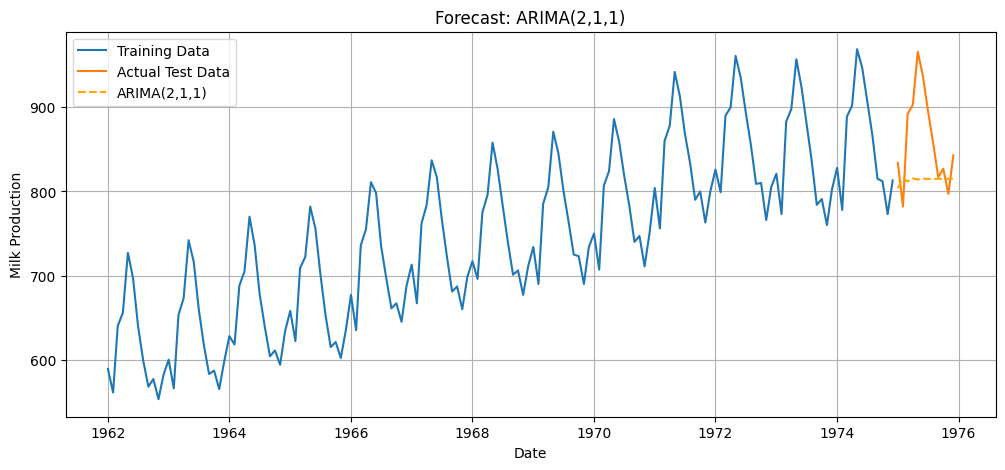

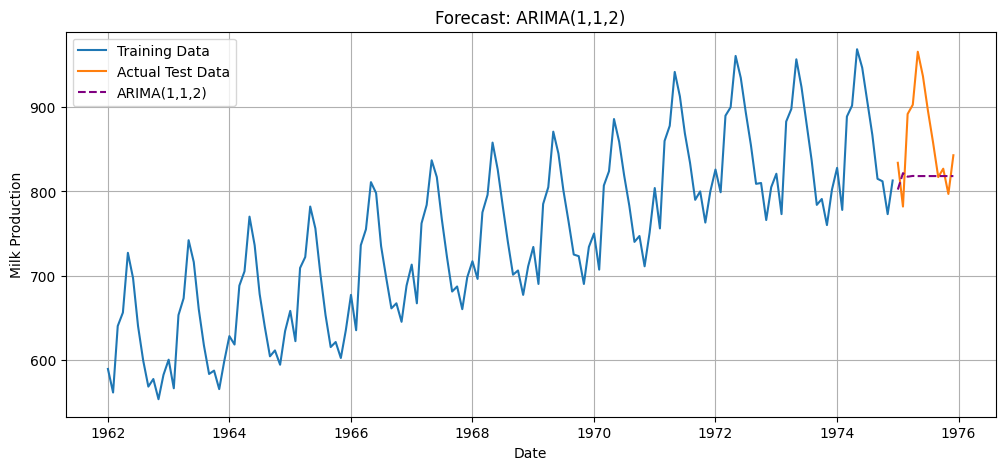

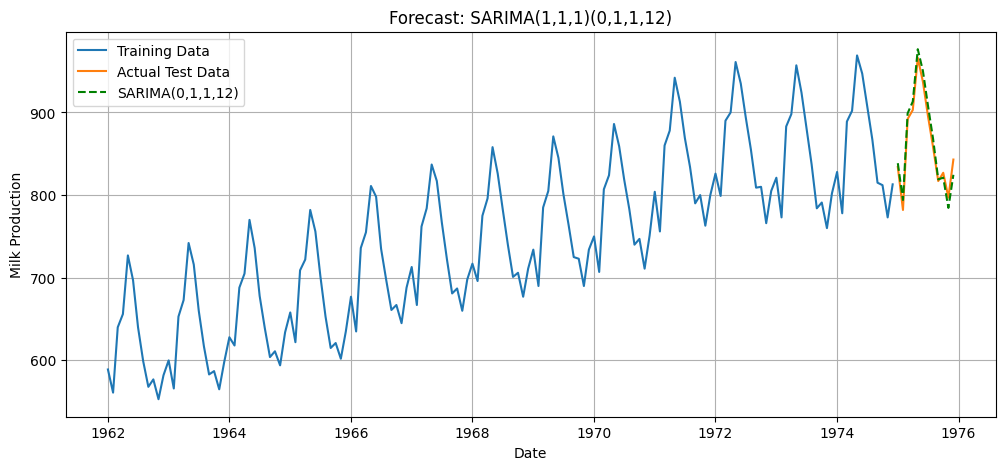

In [ ]:
# Plot for ARIMA(2,1,1)
plt.figure(figsize=(12, 5))
plt.plot(train, label='Training Data')
plt.plot(test, label='Actual Test Data')
plt.plot(test.index, forecast_1, label='ARIMA(2,1,1)', linestyle='--', color='orange')
plt.title('Forecast: ARIMA(2,1,1)')
plt.xlabel('Date')
plt.ylabel('Milk Production')
plt.legend()
plt.grid(True)
plt.show()

# Plot for ARIMA(1,1,2)
plt.figure(figsize=(12, 5))
plt.plot(train, label='Training Data')
plt.plot(test, label='Actual Test Data')
plt.plot(test.index, forecast_2, label='ARIMA(1,1,2)', linestyle='--', color='purple')
plt.title('Forecast: ARIMA(1,1,2)')
plt.xlabel('Date')
plt.ylabel('Milk Production')
plt.legend()
plt.grid(True)
plt.show()

# Plot for SARIMA(1,1,1)(0,1,1,12)
plt.figure(figsize=(12, 5))
plt.plot(train, label='Training Data')
plt.plot(test, label='Actual Test Data')
plt.plot(test.index, forecast_3, label='SARIMA(0,1,1,12)', linestyle='--', color='green')
plt.title('Forecast: SARIMA(1,1,1)(0,1,1,12)')
plt.xlabel('Date')
plt.ylabel('Milk Production')
plt.legend()
plt.grid(True)
plt.show()


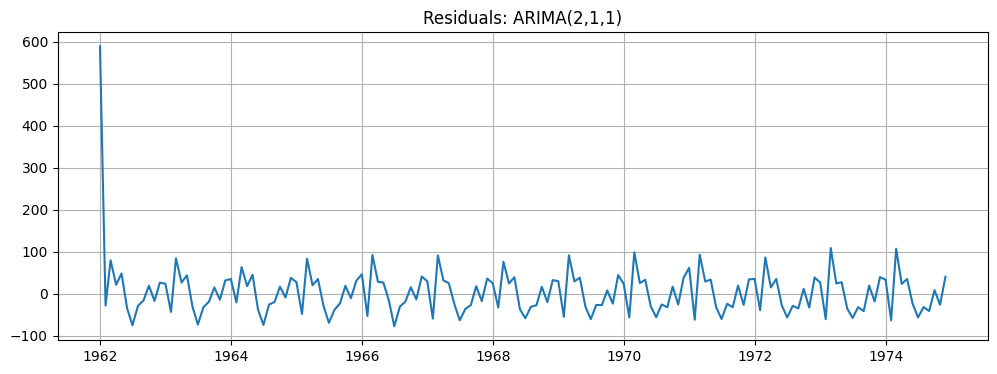

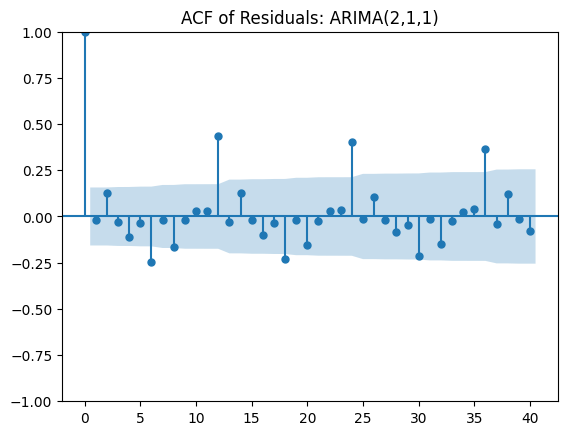

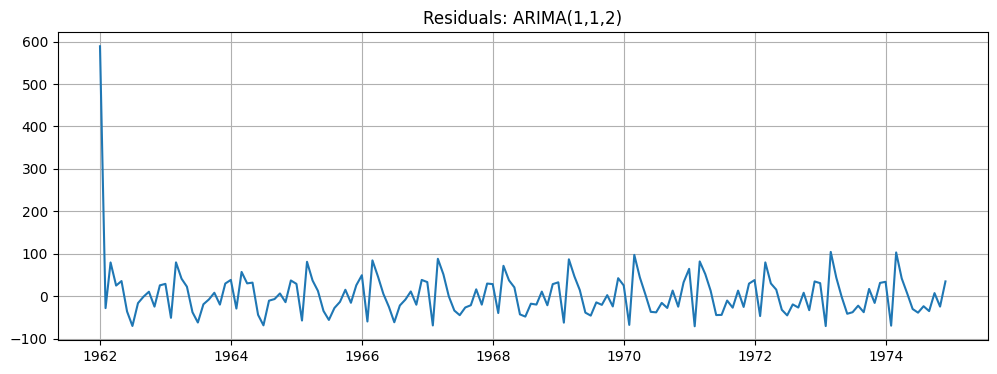

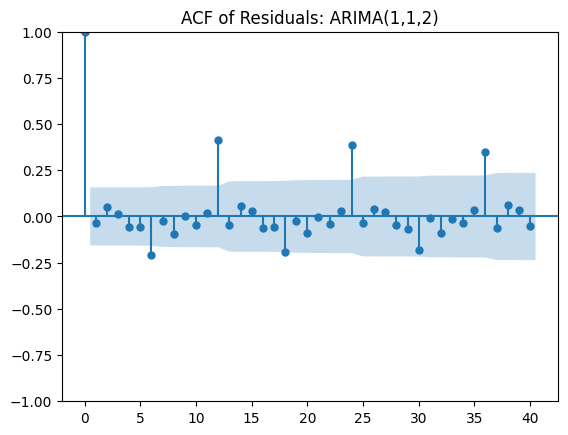

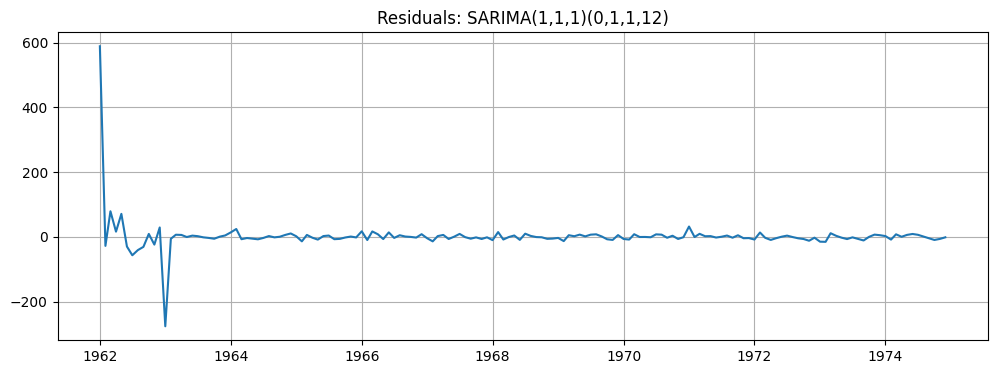

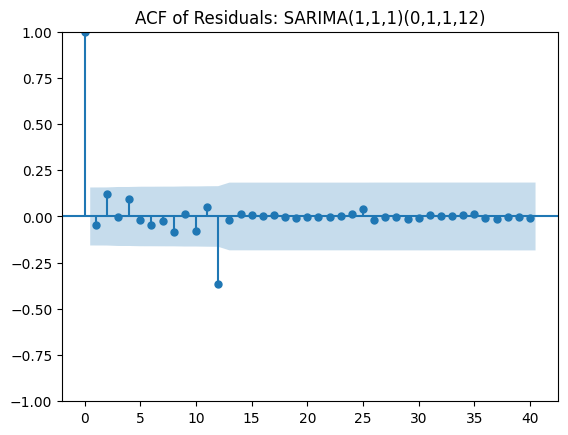

In [ ]:
residuals_1 = model_1.resid

plt.figure(figsize=(12, 4))
plt.plot(residuals_1)
plt.title("Residuals: ARIMA(2,1,1)")
plt.grid(True)
plt.show()

plot_acf(residuals_1, lags=40)
plt.title("ACF of Residuals: ARIMA(2,1,1)")
plt.show()


residuals_2 = model_2.resid

plt.figure(figsize=(12, 4))
plt.plot(residuals_2)
plt.title("Residuals: ARIMA(1,1,2)")
plt.grid(True)
plt.show()

plot_acf(residuals_2, lags=40)
plt.title("ACF of Residuals: ARIMA(1,1,2)")
plt.show()


residuals_3 = model_3.resid

plt.figure(figsize=(12, 4))
plt.plot(residuals_3)
plt.title("Residuals: SARIMA(1,1,1)(0,1,1,12)")
plt.grid(True)
plt.show()

plot_acf(residuals_3, lags=40)
plt.title("ACF of Residuals: SARIMA(1,1,1)(0,1,1,12)")
plt.show()



1. SARIMA(1,1,1)(1,1,1,2) gave the best forecast performance

2. ARIMA MODELS - Increasing model complexity from(1,1,1) to (1,1,2) or (2,1,1) slightly better performance
However it is significantly worse than SARIMA models.

  SARIMA MODELS- Adding seasonal commponets drastically reduce all errors.

  Moving from (0,1,1,12) to (1,1,1,12) improves better result in capturing both effect.

3.ARIMA RESIDUALS - Indicate that ARIMA models are missing the seasonal structure

  SARIMA RESIDUALS - No strong autocorrelation which implies better model fit


### Model Stability Across Test Sizes

Change the test data size and check if the model performance is stable.

- Try at least two patterns:
  - Example 1: Test size = last 6 months
  - Example 2: Test size = last 12 months
- Compare the forecast accuracy for each case.

#### Analysis Notes:
- Does the model performance remain stable when the test size changes?
- Does the model tend to perform better with shorter or longer forecasts?
- What can you learn about the model’s long-term forecasting ability?

Add new columns below and analyze freely.


In [ ]:
train_6 = df.iloc[:-6]
test_6 = df.iloc[-6:]
sarima_6 = SARIMAX(train_6, order=(1, 1, 1), seasonal_order=(0, 1, 1, 12)).fit()
forecast_6 = sarima_6.forecast(steps=len(test_6))
mae_6= mean_absolute_error(test_6, forecast_6)
rmse_6 = np.sqrt(mean_squared_error(test_6, forecast_6))
mape_6 = mean_absolute_percentage_error(test_6, forecast_6)


print("\nTest Size Comparison:")
print(f"{'Test Size':15s} {'MAE':>8s} {'RMSE':>8s} {'MAPE':>8s}")
print(f"{'6 months':15s} {mae_6:8.2f} {rmse_6:8.2f} {mape_6:8.2%}")
print(f"{'12 months':15s} {mae_sarima:8.2f} {rmse_sarima:8.2f} {mape_sarima:8.2%}")




Test Size Comparison:
Test Size            MAE     RMSE     MAPE
6 months           14.72    18.59    1.79%
12 months           9.54    10.65    1.11%


1.The models remains stable but the error metric change depending on the forecast horizon

2.12 months forecast better than 6 months ,this might be period had more volatile data.

3.SARIMA model show robust long term ability.SARIMA is effective for year ahead planning.


# Summary of Tested Models and Results

## List of Tested Models

| Model Name | Parameters | MAE | RMSE | MAPE |

ARIMA-Base	  ARIMA(1,1,1)	58.91	74.86	 6.54%

ARIMA-1	      ARIMA(2,1,1)	57.43	72.86	 6.39%

ARIMA-2	      ARIMA(1,1,2)	55.89	70.72	 6.23%

SARIMA-Basic(1,1,1)(0,1,1,12)	9.90	10.78	1.15%

SARIMA-Final(1,1,1)(1,1,1,12)	9.54	10.65	1.11%

SARIMA(6mnth)(1,1,1)(1,1,1,12)14.72	18.59	1.79%

SARIMA(12mnth)(1,1,1)(1,1,1,12)9.54	10.65	1.11%


---

## Discussion

- None of the ARIMA models performed better compared as they were not able to capture seasonality


- Though parameter tuning from (1,1,1) to (1,1,2) and (2,1,1) created small improvement, MAPE was always more than 6%.

- SARIMA models brought much higher accuracy, lowering MAPE to about 1.1%.

- In a twist of events, surprisingly, the 12-month test had better accuracy (MAPE 1.11%) than the 6-month test (MAPE 1.79%).

- SARIMA strongly outperforms ARIMA on seasonal time series.

- It is robust across different forecast horizons, and robust for short- and long-range planning.
